lambda1 = 0.2772588722239781
lambda2 = 0.055451774444795626


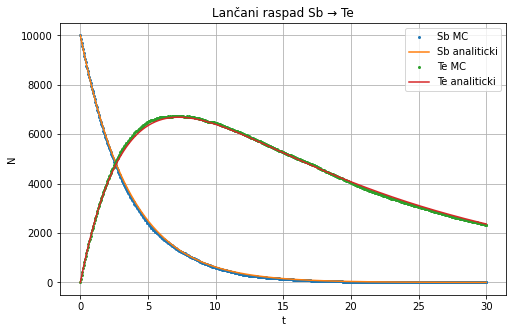

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# a) KONSTANTE RASPADA

#t poluraspada
T1 = 2.5   # Sb
T2 = 12.5  # Te

lambda1 = np.log(2) / T1
lambda2 = np.log(2) / T2

print("lambda1 =", lambda1)
print("lambda2 =", lambda2)


# PARAMETRI SIMULACIJE
#N_Sb(t) i N_Te(t) MC, usporedba s analit

N1 = 10000   # Sb
N2 = 0       # Te

dt = 0.05
tmax = 30

times = np.arange(0, tmax + dt, dt)

p1 = lambda1 * dt #vj da se rasadne u dt
p2 = lambda2 * dt

N1_list = [N1]
N2_list = [N2]


# MONTE CARLO
for t in times[1:]:

    # koliko se raspadne (binomna distribucija)
    decay1 = np.sum(np.random.rand(N1) < p1)
    #N1 slučajnih br [0,1]
    decay2 = np.sum(np.random.rand(N2) < p2)

    # update
    N1 = N1 - decay1
    N2 = N2 + decay1 - decay2

    N1_list.append(N1)
    N2_list.append(N2)

# ANALITIČKO RJEŠENJE
A1 = 10000 * np.exp(-lambda1 * times)

A2 = 10000 * (lambda1/(lambda2 - lambda1)) * (
    np.exp(-lambda1*times) - np.exp(-lambda2*times)
)

# PLOT
plt.figure(figsize=(8,5))

plt.plot(times, N1_list, 'o', markersize=2, label="Sb MC")
plt.plot(times, A1, '-', label="Sb analiticki")

plt.plot(times, N2_list, 'o', markersize=2, label="Te MC")
plt.plot(times, A2, '-', label="Te analiticki")

plt.xlabel("t")
plt.ylabel("N")
plt.title("Lančani raspad Sb → Te")
plt.legend()
plt.grid()

plt.show()